# Packages and Functions

## Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from pathlib import Path

## Functions

In [3]:
def response_to_epa_class(response_value):
    """Convert Response value to EPA toxicity class"""
    if response_value <= 50:
        return 1  # EPA Level 1
    elif response_value <= 500:
        return 2  # EPA Level 2
    elif response_value <= 5000:
        return 3  # EPA Level 3
    else:
        return 4  # EPA Level 4

def load_classification_outputs(base_folder, folder_name, bin_val, threshold_val, use_super_test=False):
    """
    Load classification outputs from the saved folder structure
    """
    # Construct folder path - the outputs are in cond_enc_1234e1e2_classification_df6
    folder_name = folder_name
    folder_path = os.path.join(base_folder, folder_name)
    
    # Convert bin_val and threshold_val to the naming format (replace . with _)
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Add EPA class from Response values
    df['EPA_class'] = df['Response'].apply(response_to_epa_class)
    
    return df

def create_confusion_matrix_plot(y_true, y_pred, class_labels=None, title="Confusion Matrix", save_path=None):
    """
    Create and display a confusion matrix plot
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Set up class labels
    if class_labels is None:
        class_labels = [f"Class {i}" for i in range(len(np.unique(y_true)))]
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return cm

def analyze_classification_results(base_folder, bin_val, threshold_val, use_super_test=False, save_plots=True):
    """
    Complete analysis function that loads outputs and creates confusion matrices
    """
    # Load the outputs
    try:
        df = load_classification_outputs(base_folder, bin_val, threshold_val, use_super_test)
        test_type = "Super Test" if use_super_test else "Regular Test"
        print(f"Loaded {test_type} outputs for bin={bin_val}, threshold={threshold_val}")
        print(f"Dataset shape: {df.shape}")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None
    
    # Define EPA toxicity class labels
    epa_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Extract true and predicted labels
    y_true = df['EPA_class'].values  # EPA class derived from Response
    y_pred = df['cond_tox_pred_class'].values  # Predicted class
    
    print(f"Using EPA classes derived from Response values")
    
    # Since true labels are 1,2,3,4 and predicted are 0,1,2,3, we need to adjust
    print(f"True label distribution: {np.bincount(y_true, minlength=5)[1:]}")  # Skip index 0
    print(f"Predicted label distribution: {np.bincount(y_pred, minlength=4)}")
    
    # Convert true labels from 1,2,3,4 to 0,1,2,3 to match predictions
    y_true_adjusted = y_true - 1
    
    # Create confusion matrix
    test_label = "Super Test" if use_super_test else "Regular Test"
    cm = create_confusion_matrix_plot(
        y_true_adjusted, y_pred, 
        class_labels=epa_labels,
        title=f"Confusion Matrix - {test_label} (Bin={bin_val}, Threshold={threshold_val})",
        save_path=f"confusion_matrix_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}.png" if save_plots else None
    )
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_adjusted, y_pred, target_names=epa_labels))
    
    # Calculate and print accuracy metrics
    accuracy = np.sum(y_true_adjusted == y_pred) / len(y_true_adjusted)
    print(f"\nOverall Accuracy: {accuracy:.4f}")
    
    # Per-class accuracy
    print("\nPer-class Accuracy:")
    for i, label in enumerate(epa_labels):
        class_mask = y_true_adjusted == i
        if np.sum(class_mask) > 0:
            class_acc = np.sum((y_true_adjusted == y_pred) & class_mask) / np.sum(class_mask)
            print(f"{label}: {class_acc:.4f}")
    
    return df, cm

def compare_multiple_configurations(base_folder, bin_threshold_pairs, use_super_test=False, save_plots=True):
    """
    Compare results across multiple bin/threshold configurations
    """
    results = {}
    
    for bin_val, threshold_val in bin_threshold_pairs:
        print(f"\n{'='*50}")
        print(f"Analyzing Bin={bin_val}, Threshold={threshold_val}")
        print(f"{'='*50}")
        
        try:
            df, cm = analyze_classification_results(base_folder, bin_val, threshold_val, use_super_test, save_plots)
            if df is not None:
                y_true = df['EPA_class'].values - 1  # Convert from 1,2,3,4 to 0,1,2,3
                y_pred = df['cond_tox_pred_class'].values
                accuracy = np.sum(y_true == y_pred) / len(y_true)
                
                results[(bin_val, threshold_val)] = {
                    'accuracy': accuracy,
                    'confusion_matrix': cm,
                    'dataframe': df
                }
                
        except Exception as e:
            print(f"Error processing bin={bin_val}, threshold={threshold_val}: {e}")
    
    # Summary comparison
    if results:
        print(f"\n{'='*60}")
        print("SUMMARY COMPARISON")
        print(f"{'='*60}")
        print(f"{'Bin':<8} {'Threshold':<12} {'Accuracy':<10}")
        print("-" * 30)
        
        for (bin_val, threshold_val), metrics in results.items():
            print(f"{bin_val:<8} {threshold_val:<12} {metrics['accuracy']:.4f}")
    
    return results

def visualize_classification(folder, bin_size, threshold_size, use_super_test=False, save_plots=True):
    """
    Main visualization function that takes folder, bin size, and threshold size
    
    Parameters:
    folder (str): Base folder path containing the classification outputs
    bin_size (int/float): Bin size value
    threshold_size (float): Threshold size value  
    use_super_test (bool): Whether to load super test results or regular test results
    save_plots (bool): Whether to save plots as PNG files
    
    Returns:
    tuple: DataFrame and confusion matrix from the analysis
    """
    test_type = "Super Test" if use_super_test else "Regular Test"
    print(f"Analyzing {test_type} classification results:")
    print(f"Folder: {folder}")
    print(f"Bin size: {bin_size}")
    print(f"Threshold size: {threshold_size}")
    print("-" * 50)
    
    # Run the analysis
    df, cm = analyze_classification_results(folder, bin_size, threshold_size, use_super_test, save_plots)
    
    return df, cm

In [3]:
# Create percentage-based confusion matrix heatmap
def create_percentage_confusion_matrix_standalone(folder, folder_name, bin_size, threshold_size, use_super_test=False, save_plots=True):
    """
    Standalone function to create percentage confusion matrix from classification outputs
    Each row shows how the actual label was distributed across predictions
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    
    def response_to_epa_class_local(response_value):
        """Convert Response value to EPA toxicity class"""
        if response_value <= 50:
            return 1  # EPA Level 1
        elif response_value <= 500:
            return 2  # EPA Level 2
        elif response_value <= 5000:
            return 3  # EPA Level 3
        else:
            return 4  # EPA Level 4
    
    # Load the classification outputs
    folder_name = folder_name
    folder_path = os.path.join(folder, folder_name)
    
    # Convert bin_size and threshold_size to the naming format (replace . with _)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Add EPA class from Response values
    df['EPA_class'] = df['Response'].apply(response_to_epa_class_local)
    
    # Extract and adjust labels
    y_true = df['EPA_class'].values - 1  # Convert from 1,2,3,4 to 0,1,2,3
    y_pred = df['cond_tox_pred_class'].values
    
    # Define EPA labels
    class_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'})
    
    test_type = "Super Test" if use_super_test else "Regular Test"
    plt.title(f"Confusion Matrix - {test_type} Percentages (Bin={bin_size}, Threshold={threshold_size})")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown with proportions
    print(f"\nPercentage breakdown by actual label (Bin={bin_size}, Threshold={threshold_size}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    return cm_percent, df



# Conditional Encoder 1234e1e2 Classifier

## Confusion Matricies

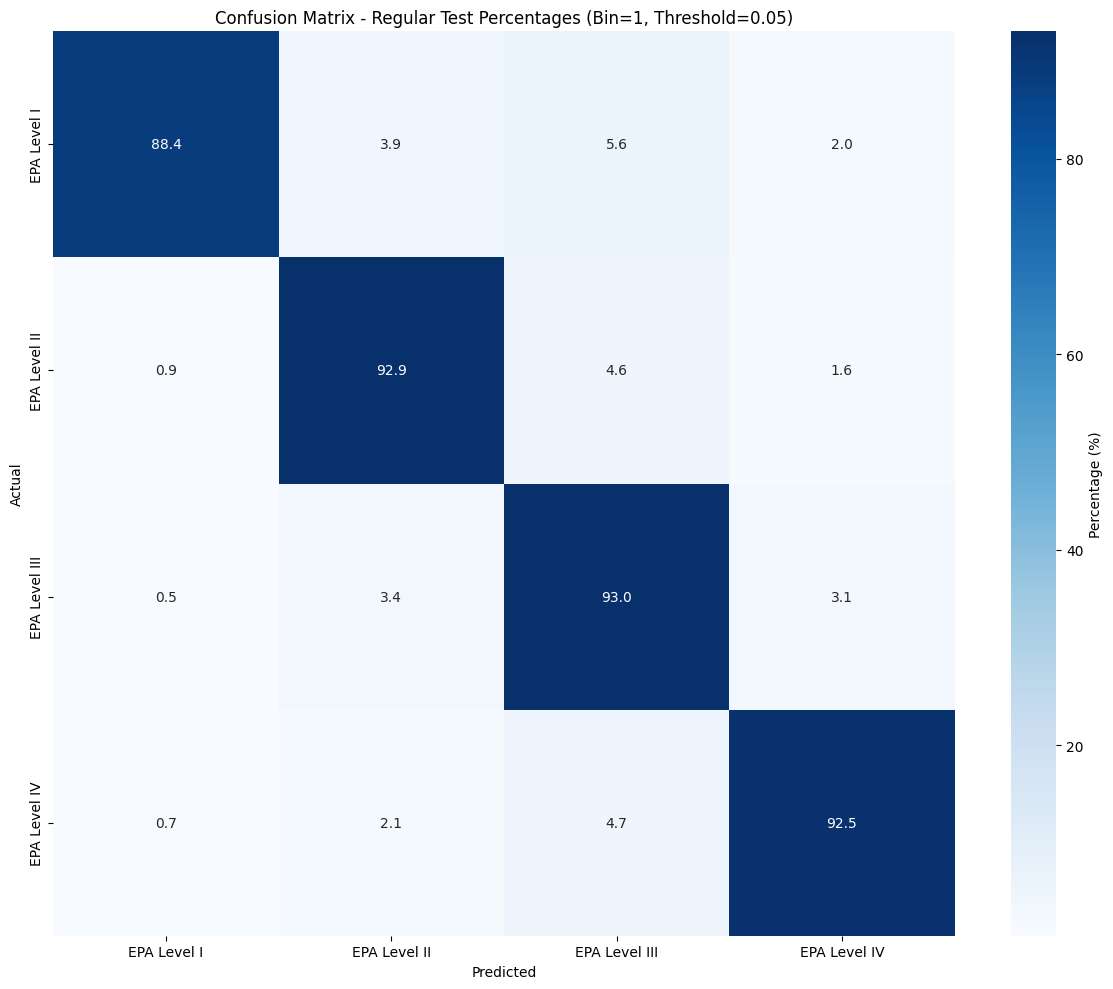


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

EPA Level I (Total: 836 samples):
  → EPA Level I: 88.4% (739/836 samples)
  → EPA Level II: 3.9% (33/836 samples)
  → EPA Level III: 5.6% (47/836 samples)
  → EPA Level IV: 2.0% (17/836 samples)

EPA Level II (Total: 3488 samples):
  → EPA Level I: 0.9% (31/3488 samples)
  → EPA Level II: 92.9% (3241/3488 samples)
  → EPA Level III: 4.6% (161/3488 samples)
  → EPA Level IV: 1.6% (55/3488 samples)

EPA Level III (Total: 8128 samples):
  → EPA Level I: 0.5% (44/8128 samples)
  → EPA Level II: 3.4% (273/8128 samples)
  → EPA Level III: 93.0% (7560/8128 samples)
  → EPA Level IV: 3.1% (251/8128 samples)

EPA Level IV (Total: 2407 samples):
  → EPA Level I: 0.7% (16/2407 samples)
  → EPA Level II: 2.1% (50/2407 samples)
  → EPA Level III: 4.7% (114/2407 samples)
  → EPA Level IV: 92.5% (2227/2407 samples)


In [4]:
# Regular Test Percentage Confusion Matrix
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="cond_enc_1234e1e2_classification_df6",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=False,
    save_plots=False
)

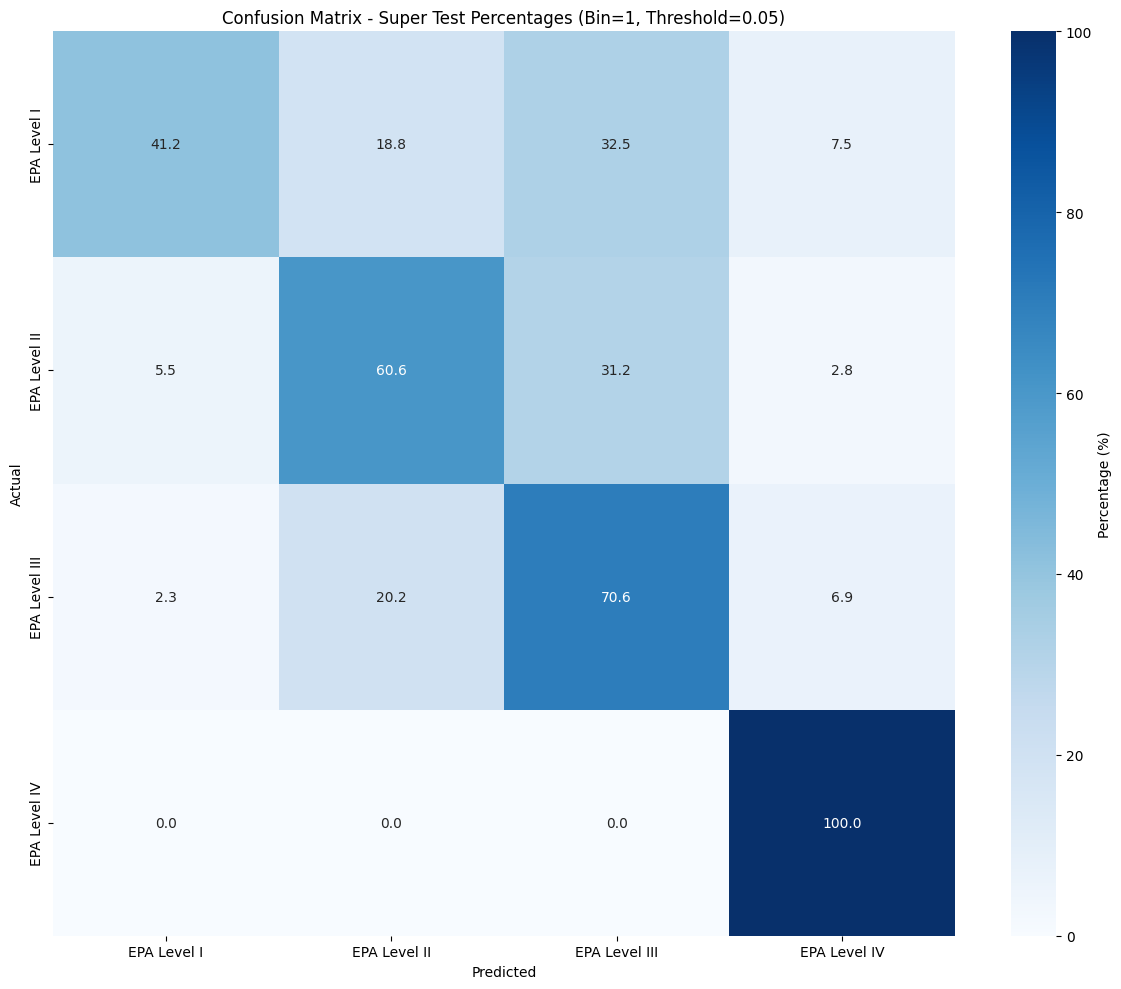


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

EPA Level I (Total: 80 samples):
  → EPA Level I: 41.2% (33/80 samples)
  → EPA Level II: 18.8% (15/80 samples)
  → EPA Level III: 32.5% (26/80 samples)
  → EPA Level IV: 7.5% (6/80 samples)

EPA Level II (Total: 109 samples):
  → EPA Level I: 5.5% (6/109 samples)
  → EPA Level II: 60.6% (66/109 samples)
  → EPA Level III: 31.2% (34/109 samples)
  → EPA Level IV: 2.8% (3/109 samples)

EPA Level III (Total: 218 samples):
  → EPA Level I: 2.3% (5/218 samples)
  → EPA Level II: 20.2% (44/218 samples)
  → EPA Level III: 70.6% (154/218 samples)
  → EPA Level IV: 6.9% (15/218 samples)

EPA Level IV (Total: 6 samples):
  → EPA Level I: 0.0% (0/6 samples)
  → EPA Level II: 0.0% (0/6 samples)
  → EPA Level III: 0.0% (0/6 samples)
  → EPA Level IV: 100.0% (6/6 samples)


In [5]:
# Super Test Percentage Confusion Matrix
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="cond_enc_1234e1e2_classification_df6_super_test",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=True,
    save_plots=False
)

## Heatmap

### Heatmap Function

In [6]:
# Modified Configurable Accuracy Heatmap Function with Super Test Support
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

def response_to_epa_class_local_v2(response_value):
    """Convert Response value to EPA toxicity class"""
    if response_value <= 50:
        return 1  # EPA Level 1
    elif response_value <= 500:
        return 2  # EPA Level 2
    elif response_value <= 5000:
        return 3  # EPA Level 3
    else:
        return 4  # EPA Level 4

def calculate_class_accuracy_v2(y_true, y_pred, target_class):
    """Calculate accuracy for a specific class"""
    # Convert to 0-based indexing
    target_class_idx = target_class - 1
    
    # Get mask for samples that actually belong to target class
    class_mask = y_true == target_class_idx
    
    if np.sum(class_mask) == 0:
        return np.nan  # No samples of this class
    
    # Calculate accuracy for this class (correct predictions / total actual samples of this class)
    correct_for_class = np.sum((y_true == y_pred) & class_mask)
    total_for_class = np.sum(class_mask)
    
    return correct_for_class / total_for_class

def parse_cond_enc_classification_dataset_name_v2(dataset_name, use_super_test=False):
    """Extract bin size and threshold from conditional encoder classification dataset name"""
    # Remove 'super_test_' prefix if present
    if use_super_test and dataset_name.startswith('super_test_'):
        name_part = dataset_name.replace('super_test_cond_enc_', '')
    else:
        # Remove 'cond_enc_' prefix
        name_part = dataset_name.replace('cond_enc_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

def load_and_process_classification_data_v2(folder_path, use_super_test=False):
    """Load and process classification data from the specified folder"""
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"Error: Folder {folder_path} does not exist!")
        return pd.DataFrame()
    
    # Get all .parquet files in the folder
    parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]
    
    # Filter files based on whether we want super test or regular test
    if use_super_test:
        # Only include files that start with 'super_test_'
        dataset_names = [f.replace('.parquet', '') for f in parquet_files if f.startswith('super_test_')]
    else:
        # Only include files that start with 'cond_enc_' but NOT 'super_test_'
        dataset_names = [f.replace('.parquet', '') for f in parquet_files 
                        if f.startswith('cond_enc_') and not f.startswith('super_test_')]

    if not dataset_names:
        test_type = "super test" if use_super_test else "regular"
        print(f"Warning: No {test_type} .parquet files found in {folder_path}")
        return pd.DataFrame()

    # Initialize storage for classification results
    classification_results = []

    # Process classification datasets
    for i, dataset_name in enumerate(sorted(dataset_names), 1):
        try:
            # Load the classification dataset
            file_path = os.path.join(folder_path, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)
            
            # Check if required columns exist
            if 'cond_tox_pred_class' not in df.columns:
                print(f"  Warning: 'cond_tox_pred_class' column not found, skipping...")
                continue
            
            if 'Response' not in df.columns:
                print(f"  Warning: 'Response' column not found, skipping...")
                continue
            
            # Get predictions and true values
            y_pred_class = df['cond_tox_pred_class']  # Predicted EPA classes
            y_true_response = df['Response']  # True toxicity values
            
            # Convert true response values to EPA classes
            y_true_class = y_true_response.apply(response_to_epa_class_local_v2)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_class.isna() | y_true_class.isna())
            y_pred_class_clean = y_pred_class[valid_mask]
            y_true_class_clean = y_true_class[valid_mask]
            
            if len(y_pred_class_clean) < 10:  # Skip if too few samples
                print(f"  Too few samples, skipping...")
                continue
            
            # Convert to 0-based indexing for sklearn functions
            y_true_class_clean_0based = y_true_class_clean - 1
            
            # Calculate overall accuracy
            overall_accuracy = accuracy_score(y_true_class_clean_0based, y_pred_class_clean)
            
            # Calculate individual class accuracies
            class1_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 1)
            class2_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 2)
            class3_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 3)
            class4_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 4)
            
            # Store results
            classification_results.append({
                'Dataset': dataset_name,
                'Overall_Accuracy': overall_accuracy,
                'Class1_Accuracy': class1_accuracy,
                'Class2_Accuracy': class2_accuracy,
                'Class3_Accuracy': class3_accuracy,
                'Class4_Accuracy': class4_accuracy,
                'Samples': len(y_pred_class_clean)
            })
            
        except Exception as e:
            print(f"  ✗ Error processing {dataset_name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(classification_results)

    if results_df.empty:
        print("Warning: No datasets were successfully processed!")
        return results_df

    # Add bin_size and threshold columns
    bin_sizes = []
    thresholds = []

    for dataset_name in results_df['Dataset']:
        bin_size, threshold = parse_cond_enc_classification_dataset_name_v2(dataset_name, use_super_test)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)

    results_df['BinSize'] = bin_sizes
    results_df['Threshold'] = thresholds

    # Remove duplicates
    results_df = results_df.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    return results_df

# Main function to create accuracy heatmap with configurable parameters and super test support
def create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='average', colormap='RdYlGn', figsize=(12, 8), use_super_test=False):
    """
    Create a detailed heatmap for Classification Accuracy with support for super test datasets
    
    Parameters:
    folder_path (str): Path to folder containing classification result files
    metric (str): Type of accuracy to plot
        - 'average': Overall accuracy
        - '1', '2', '3', '4': Individual class accuracy (EPA Level 1-4)
    colormap (str): Color scheme for the heatmap (e.g., 'RdYlGn', 'viridis', 'Blues', 'Reds', 'Greens', 'Purples')
    figsize (tuple): Figure size as (width, height)
    use_super_test (bool): Whether to load super test datasets (files starting with 'super_test_') or regular datasets
    
    Returns:
    pandas.DataFrame: Pivot table with accuracy data, or None if no data available
    """
    
    # Load and process data from the specified folder
    df_results = load_and_process_classification_data_v2(folder_path, use_super_test)
    
    if df_results.empty:
        test_type = "super test" if use_super_test else "regular"
        print(f"No {test_type} data available to create heatmap!")
        print("Please ensure the folder contains valid .parquet files with required columns.")
        return None
    
    # Map metric types to column names and display names
    metric_mapping = {
        'average': ('Overall_Accuracy', 'Overall Accuracy'),
        '1': ('Class1_Accuracy', 'EPA Level I Accuracy'),
        '2': ('Class2_Accuracy', 'EPA Level II Accuracy'),
        '3': ('Class3_Accuracy', 'EPA Level III Accuracy'),
        '4': ('Class4_Accuracy', 'EPA Level IV Accuracy')
    }
    
    if metric not in metric_mapping:
        raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    
    column_name, display_name = metric_mapping[metric]
    
    # Create pivot table
    accuracy_pivot = df_results.pivot(index='BinSize', columns='Threshold', values=column_name)
    
    # List all expected thresholds and bin sizes
    thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]
    
    # Reindex pivot table
    accuracy_pivot = accuracy_pivot.reindex(columns=thresholds_subset, index=bins_subset)
    
    plt.figure(figsize=figsize)
    
    # Create heatmap
    ax = sns.heatmap(accuracy_pivot, 
                     annot=True, 
                     fmt='.3f', 
                     cmap=colormap,
                     square=False,
                     linewidths=0.5,
                     vmin=0,
                     vmax=1,
                     cbar_kws={'label': display_name, 'shrink': 0.8})
    
    # Add test type to title
    test_type = "Super Test" if use_super_test else "Regular Test"
    plt.title(f'Classification Results ({test_type}): {display_name} by Bin Size and Threshold', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_acc = accuracy_pivot.max().max()
    plt.text(0.02, 0.98, f'Best {display_name}: {best_acc:.3f}', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy_pivot

### Heatmap Presentation

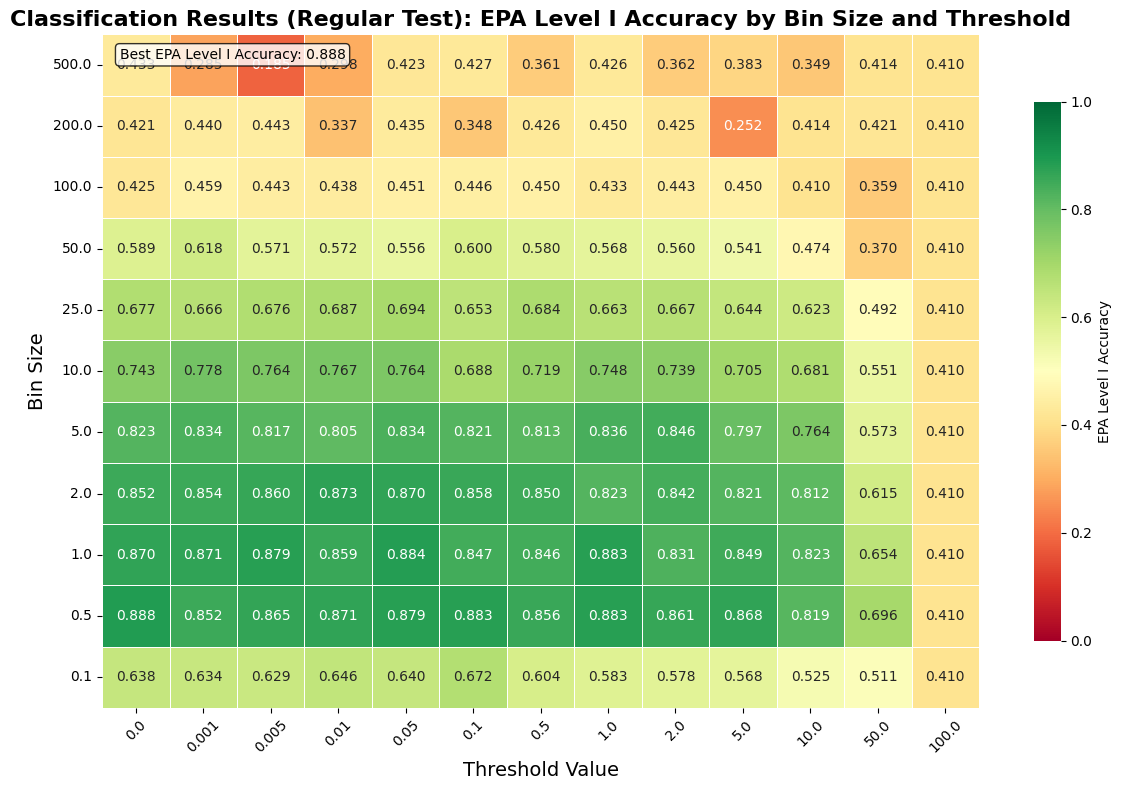

Threshold,0.000,0.001,0.005,0.010,0.050,0.100,0.500,1.000,2.000,5.000,10.000,50.000,100.000
BinSize,,,,,,,,,,,,,
0.1,0.637560,0.633971,0.629187,0.645933,0.639952,0.672249,0.604067,0.582536,0.577751,0.568182,0.525120,0.510766,0.410287
0.5,0.887560,0.851675,0.864833,0.870813,0.879187,0.882775,0.856459,0.882775,0.861244,0.868421,0.819378,0.696172,0.410287
1.0,0.869617,0.870813,0.879187,0.858852,0.883971,0.846890,0.845694,0.882775,0.831340,0.849282,0.822967,0.654306,0.410287
2.0,0.851675,0.854067,0.860048,0.873206,0.869617,0.857656,0.850478,0.822967,0.842105,0.820574,0.812201,0.614833,0.410287
5.0,0.822967,0.833732,0.816986,0.805024,0.833732,0.820574,0.813397,0.836124,0.845694,0.796651,0.764354,0.572967,0.410287
10.0,0.742823,0.777512,0.764354,0.766746,0.764354,0.687799,0.718900,0.747608,0.739234,0.704545,0.680622,0.551435,0.410287
25.0,0.677033,0.666268,0.675837,0.686603,0.693780,0.653110,0.684211,0.662679,0.667464,0.643541,0.623206,0.491627,0.410287
50.0,0.588517,0.618421,0.570574,0.571770,0.556220,0.600478,0.580144,0.568182,0.559809,0.540670,0.473684,0.369617,0.410287
100.0,0.424641,0.459330,0.442584,0.437799,0.450957,0.446172,0.449761,0.433014,0.442584,0.449761,0.410287,0.358852,0.410287


In [19]:
# Regular test datasets
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_classification_df6"
create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='1', use_super_test=False)


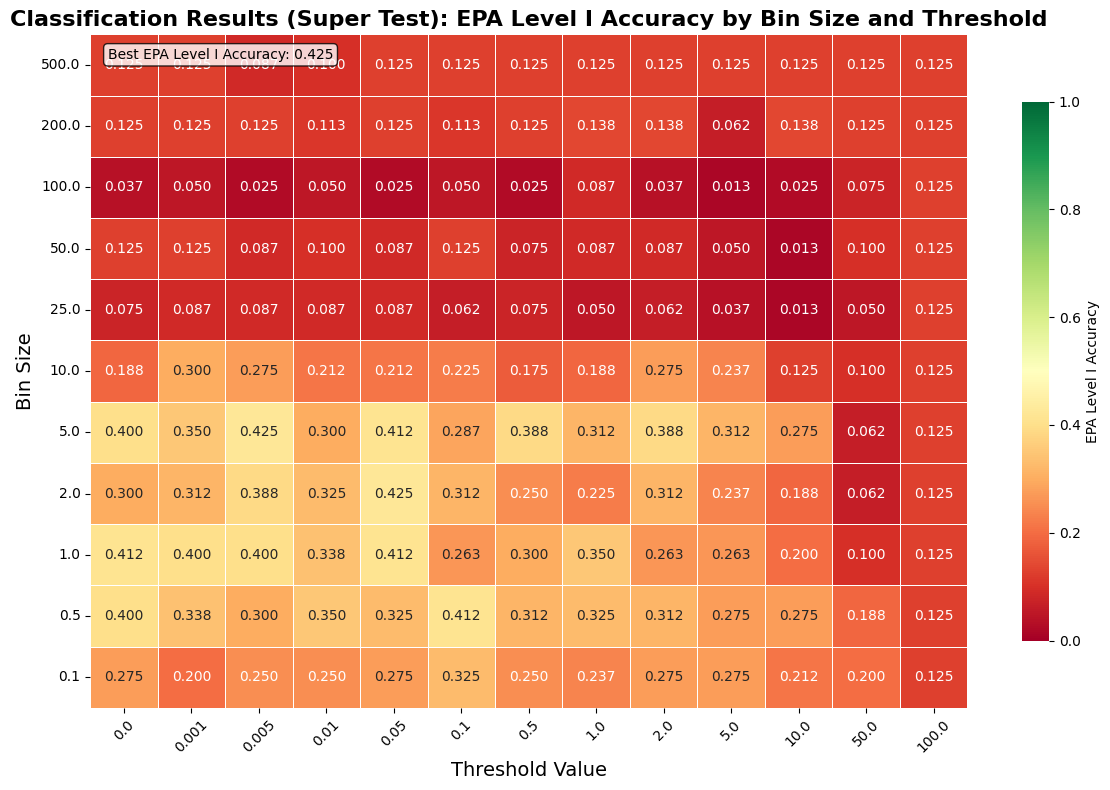

Threshold,0.000,0.001,0.005,0.010,0.050,0.100,0.500,1.000,2.000,5.000,10.000,50.000,100.000
BinSize,,,,,,,,,,,,,
0.1,0.2750,0.2000,0.2500,0.2500,0.2750,0.3250,0.2500,0.2375,0.2750,0.2750,0.2125,0.2000,0.125
0.5,0.4000,0.3375,0.3000,0.3500,0.3250,0.4125,0.3125,0.3250,0.3125,0.2750,0.2750,0.1875,0.125
1.0,0.4125,0.4000,0.4000,0.3375,0.4125,0.2625,0.3000,0.3500,0.2625,0.2625,0.2000,0.1000,0.125
2.0,0.3000,0.3125,0.3875,0.3250,0.4250,0.3125,0.2500,0.2250,0.3125,0.2375,0.1875,0.0625,0.125
5.0,0.4000,0.3500,0.4250,0.3000,0.4125,0.2875,0.3875,0.3125,0.3875,0.3125,0.2750,0.0625,0.125
10.0,0.1875,0.3000,0.2750,0.2125,0.2125,0.2250,0.1750,0.1875,0.2750,0.2375,0.1250,0.1000,0.125
25.0,0.0750,0.0875,0.0875,0.0875,0.0875,0.0625,0.0750,0.0500,0.0625,0.0375,0.0125,0.0500,0.125
50.0,0.1250,0.1250,0.0875,0.1000,0.0875,0.1250,0.0750,0.0875,0.0875,0.0500,0.0125,0.1000,0.125
100.0,0.0375,0.0500,0.0250,0.0500,0.0250,0.0500,0.0250,0.0875,0.0375,0.0125,0.0250,0.0750,0.125


In [20]:
# Super test datasets  
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_1234e1e2_classification_df6_super_test"
create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='1', use_super_test=True)

# Ablation Conditional Encoder 1234e1e2 Classifier

## Confusion Matricies

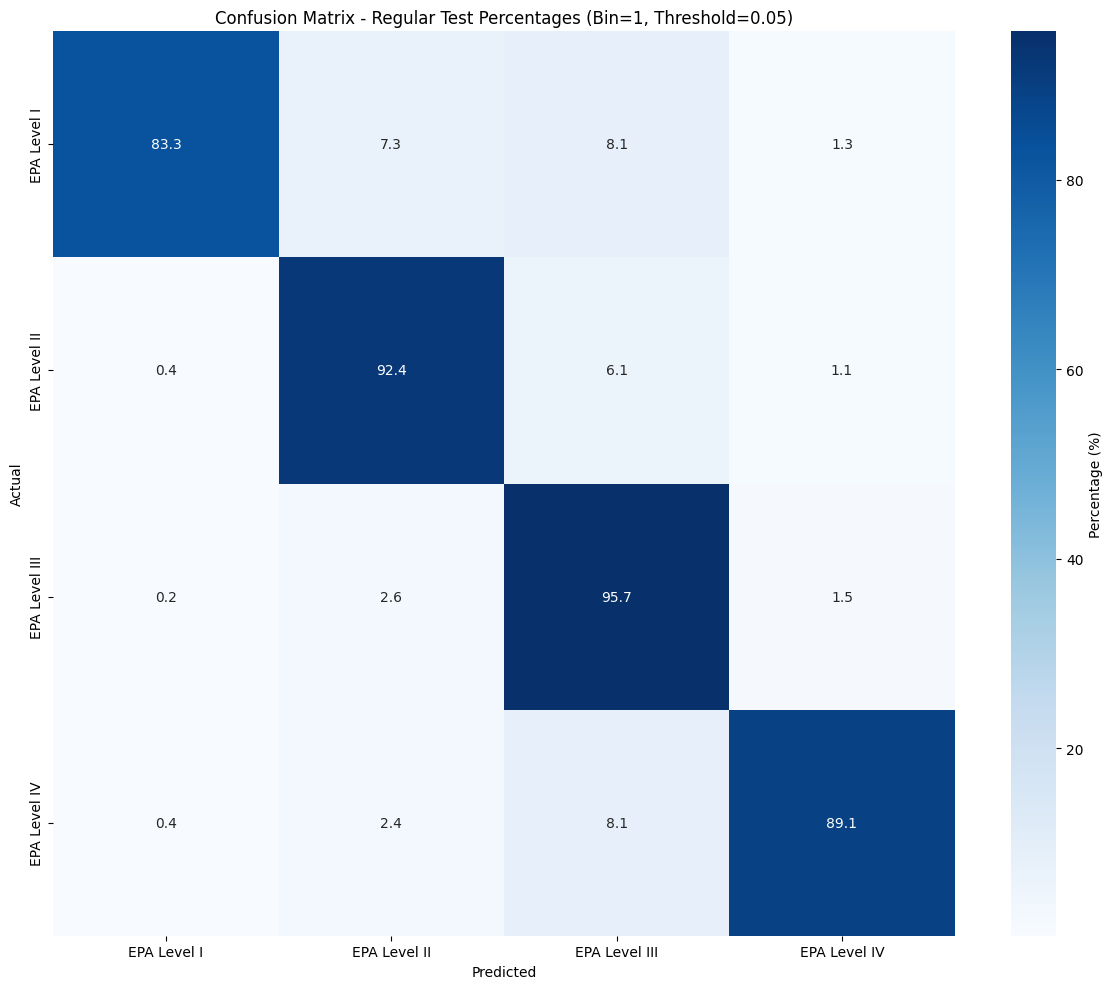


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

EPA Level I (Total: 836 samples):
  → EPA Level I: 83.3% (696/836 samples)
  → EPA Level II: 7.3% (61/836 samples)
  → EPA Level III: 8.1% (68/836 samples)
  → EPA Level IV: 1.3% (11/836 samples)

EPA Level II (Total: 3488 samples):
  → EPA Level I: 0.4% (15/3488 samples)
  → EPA Level II: 92.4% (3222/3488 samples)
  → EPA Level III: 6.1% (212/3488 samples)
  → EPA Level IV: 1.1% (39/3488 samples)

EPA Level III (Total: 8128 samples):
  → EPA Level I: 0.2% (18/8128 samples)
  → EPA Level II: 2.6% (215/8128 samples)
  → EPA Level III: 95.7% (7775/8128 samples)
  → EPA Level IV: 1.5% (120/8128 samples)

EPA Level IV (Total: 2407 samples):
  → EPA Level I: 0.4% (10/2407 samples)
  → EPA Level II: 2.4% (57/2407 samples)
  → EPA Level III: 8.1% (196/2407 samples)
  → EPA Level IV: 89.1% (2144/2407 samples)


In [9]:
# Regular Test Percentage Confusion Matrix
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="ablation_classifier_1234e1e2_df6",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=False,
    save_plots=False
)

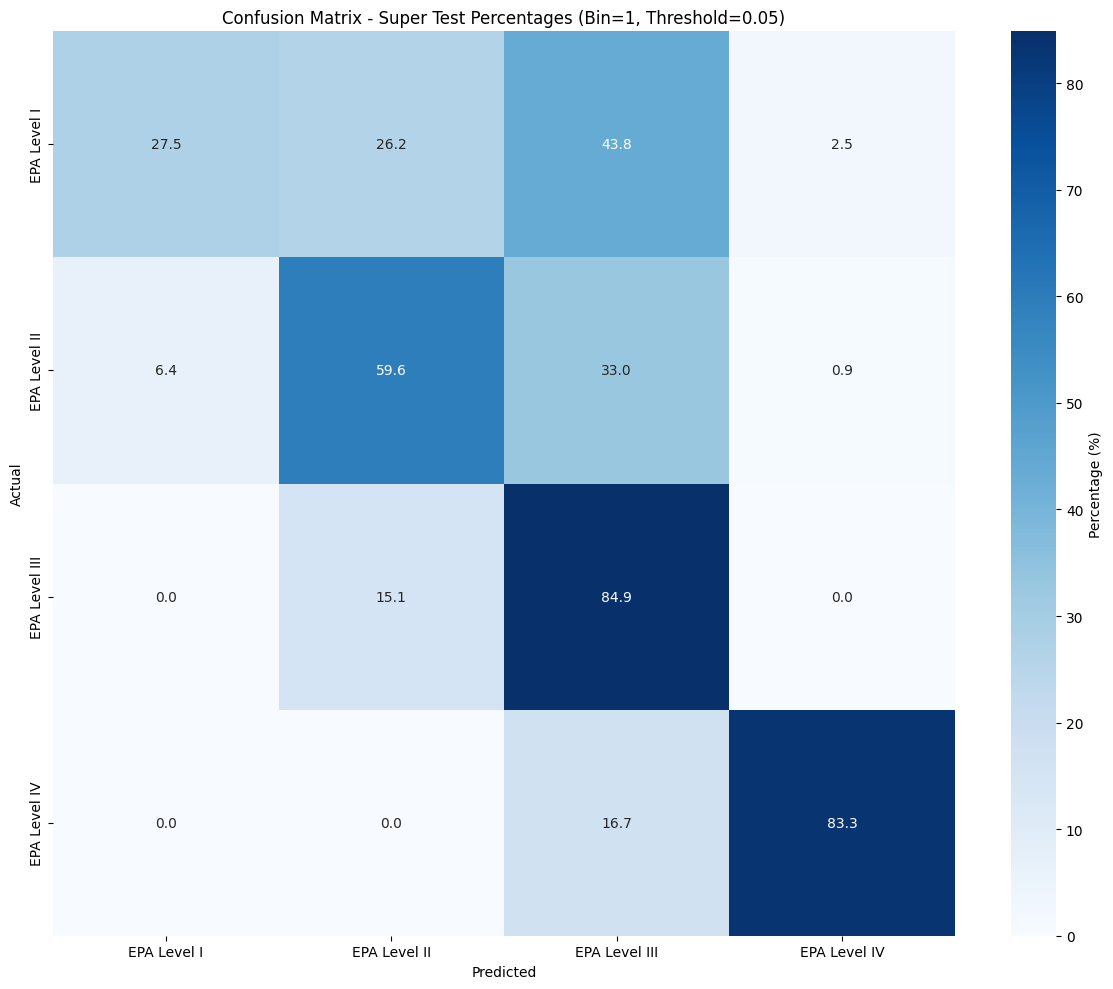


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

EPA Level I (Total: 80 samples):
  → EPA Level I: 27.5% (22/80 samples)
  → EPA Level II: 26.2% (21/80 samples)
  → EPA Level III: 43.8% (35/80 samples)
  → EPA Level IV: 2.5% (2/80 samples)

EPA Level II (Total: 109 samples):
  → EPA Level I: 6.4% (7/109 samples)
  → EPA Level II: 59.6% (65/109 samples)
  → EPA Level III: 33.0% (36/109 samples)
  → EPA Level IV: 0.9% (1/109 samples)

EPA Level III (Total: 218 samples):
  → EPA Level I: 0.0% (0/218 samples)
  → EPA Level II: 15.1% (33/218 samples)
  → EPA Level III: 84.9% (185/218 samples)
  → EPA Level IV: 0.0% (0/218 samples)

EPA Level IV (Total: 6 samples):
  → EPA Level I: 0.0% (0/6 samples)
  → EPA Level II: 0.0% (0/6 samples)
  → EPA Level III: 16.7% (1/6 samples)
  → EPA Level IV: 83.3% (5/6 samples)


In [10]:
# Super Test Percentage Confusion Matrix
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="ablation_classifier_1234e1e2_df6_super_test",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=True,
    save_plots=False
)

## Heatmap

### Heatmap Function

In [11]:
# In the previous cell

### Heatmap Creation

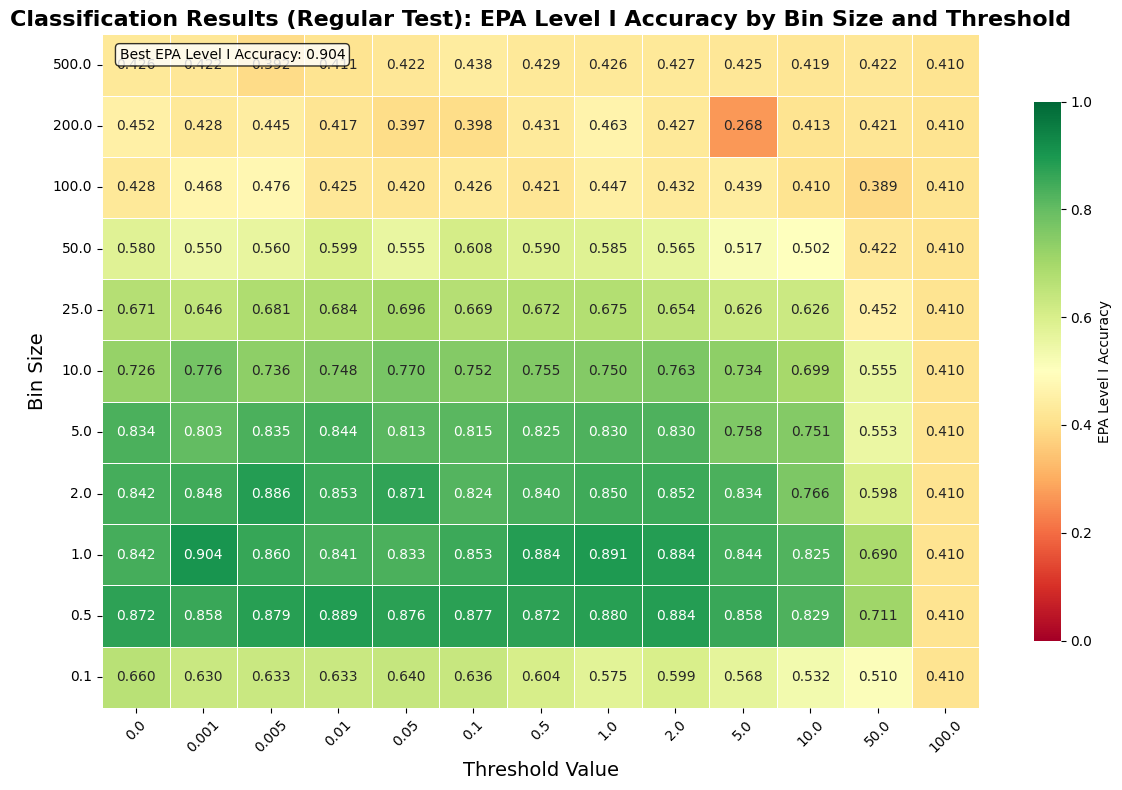

Threshold,0.000,0.001,0.005,0.010,0.050,0.100,0.500,1.000,2.000,5.000,10.000,50.000,100.000
BinSize,,,,,,,,,,,,,
0.1,0.660287,0.630383,0.632775,0.632775,0.639952,0.636364,0.604067,0.575359,0.599282,0.568182,0.532297,0.509569,0.410287
0.5,0.872010,0.857656,0.879187,0.888756,0.875598,0.876794,0.872010,0.880383,0.883971,0.857656,0.828947,0.710526,0.410287
1.0,0.842105,0.904306,0.860048,0.840909,0.832536,0.852871,0.883971,0.891148,0.883971,0.844498,0.825359,0.690191,0.410287
2.0,0.842105,0.848086,0.886364,0.852871,0.870813,0.824163,0.839713,0.850478,0.851675,0.833732,0.765550,0.598086,0.410287
5.0,0.833732,0.802632,0.834928,0.844498,0.813397,0.814593,0.825359,0.830144,0.830144,0.758373,0.751196,0.552632,0.410287
10.0,0.726077,0.776316,0.735646,0.747608,0.770335,0.752392,0.754785,0.750000,0.763158,0.734450,0.698565,0.555024,0.410287
25.0,0.671053,0.645933,0.680622,0.684211,0.696172,0.668660,0.672249,0.674641,0.654306,0.625598,0.625598,0.452153,0.410287
50.0,0.580144,0.550239,0.559809,0.599282,0.555024,0.607656,0.589713,0.584928,0.564593,0.516746,0.502392,0.422249,0.410287
100.0,0.428230,0.467703,0.476077,0.424641,0.419856,0.425837,0.421053,0.447368,0.431818,0.438995,0.410287,0.388756,0.410287


In [18]:
# Regular test datasets
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/ablation_classifier_1234e1e2_df6"
create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='1', use_super_test=False)

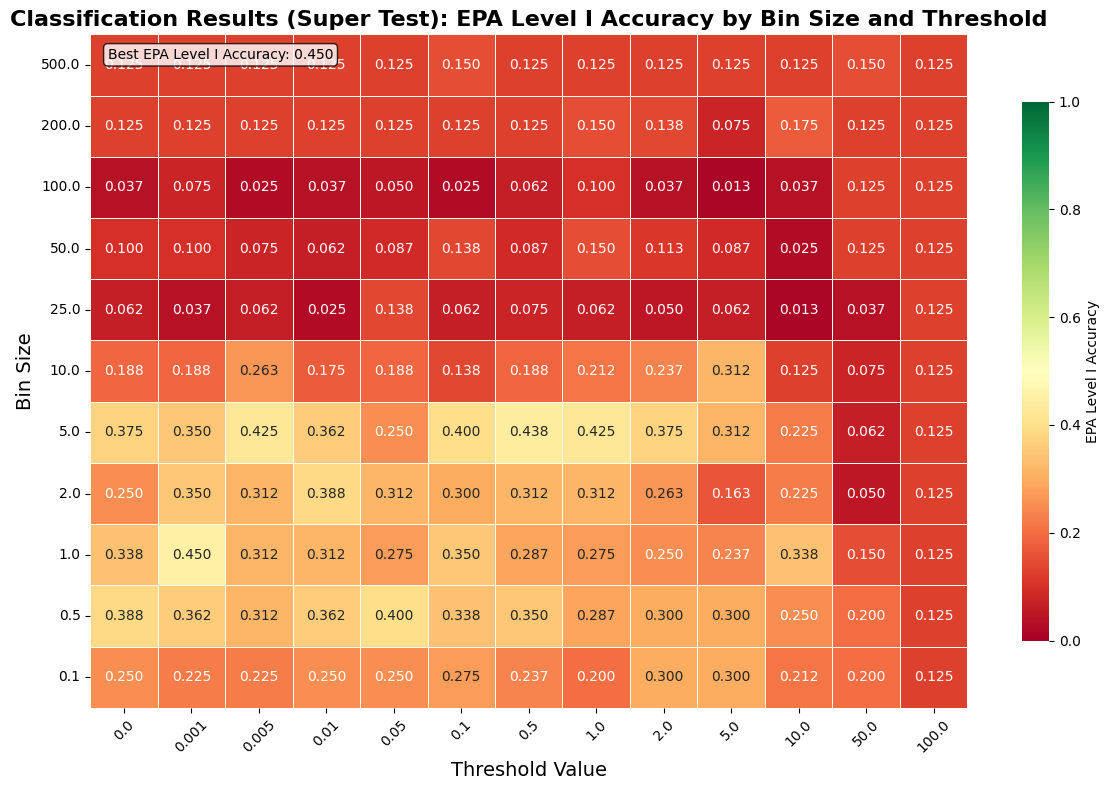

Threshold,0.000,0.001,0.005,0.010,0.050,0.100,0.500,1.000,2.000,5.000,10.000,50.000,100.000
BinSize,,,,,,,,,,,,,
0.1,0.2500,0.2250,0.2250,0.2500,0.2500,0.2750,0.2375,0.2000,0.3000,0.3000,0.2125,0.2000,0.125
0.5,0.3875,0.3625,0.3125,0.3625,0.4000,0.3375,0.3500,0.2875,0.3000,0.3000,0.2500,0.2000,0.125
1.0,0.3375,0.4500,0.3125,0.3125,0.2750,0.3500,0.2875,0.2750,0.2500,0.2375,0.3375,0.1500,0.125
2.0,0.2500,0.3500,0.3125,0.3875,0.3125,0.3000,0.3125,0.3125,0.2625,0.1625,0.2250,0.0500,0.125
5.0,0.3750,0.3500,0.4250,0.3625,0.2500,0.4000,0.4375,0.4250,0.3750,0.3125,0.2250,0.0625,0.125
10.0,0.1875,0.1875,0.2625,0.1750,0.1875,0.1375,0.1875,0.2125,0.2375,0.3125,0.1250,0.0750,0.125
25.0,0.0625,0.0375,0.0625,0.0250,0.1375,0.0625,0.0750,0.0625,0.0500,0.0625,0.0125,0.0375,0.125
50.0,0.1000,0.1000,0.0750,0.0625,0.0875,0.1375,0.0875,0.1500,0.1125,0.0875,0.0250,0.1250,0.125
100.0,0.0375,0.0750,0.0250,0.0375,0.0500,0.0250,0.0625,0.1000,0.0375,0.0125,0.0375,0.1250,0.125


In [22]:
# Super test datasets  
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/ablation_classifier_1234e1e2_df6_super_test"
create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='1', use_super_test=True)

# Base Random Forest Classifier

## Confusion Matricies

In [4]:
# Create percentage-based confusion matrix heatmap for Random Forest results
def create_percentage_confusion_matrix_random_forest(folder, folder_name, bin_size, threshold_size, save_plots=True):
    """
    Standalone function to create percentage confusion matrix from random forest classification outputs
    Each row shows how the actual label was distributed across predictions
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    
    def response_to_epa_class_local(response_value):
        """Convert Response value to EPA toxicity class"""
        if response_value <= 50:
            return 1  # EPA Level 1
        elif response_value <= 500:
            return 2  # EPA Level 2
        elif response_value <= 5000:
            return 3  # EPA Level 3
        else:
            return 4  # EPA Level 4
    
    # Load the random forest classification outputs
    folder_path = os.path.join(folder, folder_name)
    
    # Convert bin_size and threshold_size to the naming format (replace . with _)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Random forest file naming pattern
    filename = f"rf_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Get true labels - prioritize EPA_level if available, otherwise derive from Response
    if 'EPA_level' in df.columns:
        y_true_raw = df['EPA_level'].values  # Should be 1,2,3,4
    else:
        # Derive EPA class from Response values
        df['EPA_class'] = df['Response'].apply(response_to_epa_class_local)
        y_true_raw = df['EPA_class'].values  # Will be 1,2,3,4
    
    # Get predicted classes from random forest
    y_pred_raw = df['rf_predicted_epa_class'].values  # Assuming this is also 1,2,3,4
    
    # Convert both to 0-based indexing for sklearn
    y_true = y_true_raw - 1  # Convert from 1,2,3,4 to 0,1,2,3
    y_pred = y_pred_raw - 1  # Convert from 1,2,3,4 to 0,1,2,3
    
    # Define EPA labels
    class_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues', 
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    plt.title(f"Random Forest Confusion Matrix - Percentages\n(Bin={bin_size}, Threshold={threshold_size})", 
              fontsize=14, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_rf_bin{bin_size}_thr{threshold_size}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown with proportions
    print(f"\nRandom Forest Percentage breakdown by actual label (Bin={bin_size}, Threshold={threshold_size}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    return cm_percent, df

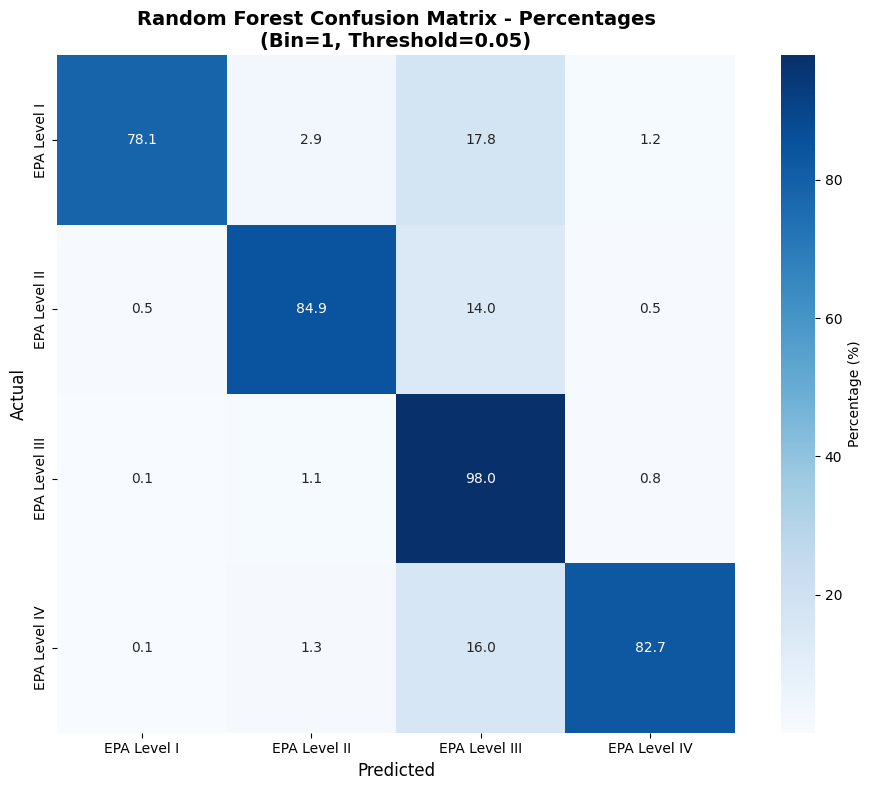


Random Forest Percentage breakdown by actual label (Bin=1, Threshold=0.05):

EPA Level I (Total: 836 samples):
  → EPA Level I: 78.1% (653/836 samples)
  → EPA Level II: 2.9% (24/836 samples)
  → EPA Level III: 17.8% (149/836 samples)
  → EPA Level IV: 1.2% (10/836 samples)

EPA Level II (Total: 3488 samples):
  → EPA Level I: 0.5% (17/3488 samples)
  → EPA Level II: 84.9% (2963/3488 samples)
  → EPA Level III: 14.0% (490/3488 samples)
  → EPA Level IV: 0.5% (18/3488 samples)

EPA Level III (Total: 8128 samples):
  → EPA Level I: 0.1% (10/8128 samples)
  → EPA Level II: 1.1% (88/8128 samples)
  → EPA Level III: 98.0% (7963/8128 samples)
  → EPA Level IV: 0.8% (67/8128 samples)

EPA Level IV (Total: 2407 samples):
  → EPA Level I: 0.1% (2/2407 samples)
  → EPA Level II: 1.3% (31/2407 samples)
  → EPA Level III: 16.0% (384/2407 samples)
  → EPA Level IV: 82.7% (1990/2407 samples)


In [15]:
# Example usage for Random Forest Confusion Matrix
# Replace with your actual folder path, folder name, and parameter values
cm_percent_rf, df_rf = create_percentage_confusion_matrix_random_forest(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="random_forest_df6",  # Update with your RF results folder name
    bin_size=1,
    threshold_size=0.05,
    save_plots=False
)

In [6]:
# Create percentage-based confusion matrix heatmap for Random Forest results
def create_percentage_confusion_matrix_random_forest(folder, folder_name, bin_size, threshold_size, save_plots=True):
    """
    Standalone function to create percentage confusion matrix from random forest classification outputs
    Each row shows how the actual label was distributed across predictions
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    
    def response_to_epa_class_local(response_value):
        """Convert Response value to EPA toxicity class"""
        if response_value <= 50:
            return 1  # EPA Level 1
        elif response_value <= 500:
            return 2  # EPA Level 2
        elif response_value <= 5000:
            return 3  # EPA Level 3
        else:
            return 4  # EPA Level 4
    
    # Load the random forest classification outputs
    folder_path = os.path.join(folder, folder_name)
    
    # Convert bin_size and threshold_size to the naming format (replace . with _)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Random forest file naming pattern
    filename = f"super_test_rf_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Get true labels - prioritize EPA_level if available, otherwise derive from Response
    if 'EPA_level' in df.columns:
        y_true_raw = df['EPA_level'].values  # Should be 1,2,3,4
    else:
        # Derive EPA class from Response values
        df['EPA_class'] = df['Response'].apply(response_to_epa_class_local)
        y_true_raw = df['EPA_class'].values  # Will be 1,2,3,4
    
    # Get predicted classes from random forest
    y_pred_raw = df['rf_predicted_epa_class'].values  # Assuming this is also 1,2,3,4
    
    # Convert both to 0-based indexing for sklearn
    y_true = y_true_raw - 1  # Convert from 1,2,3,4 to 0,1,2,3
    y_pred = y_pred_raw - 1  # Convert from 1,2,3,4 to 0,1,2,3
    
    # Define EPA labels
    class_labels = ["EPA Level I", "EPA Level II", "EPA Level III", "EPA Level IV"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues', 
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    plt.title(f"Random Forest Confusion Matrix - Percentages\n(Bin={bin_size}, Threshold={threshold_size})", 
              fontsize=14, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_rf_bin{bin_size}_thr{threshold_size}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown with proportions
    print(f"\nRandom Forest Percentage breakdown by actual label (Bin={bin_size}, Threshold={threshold_size}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    return cm_percent, df

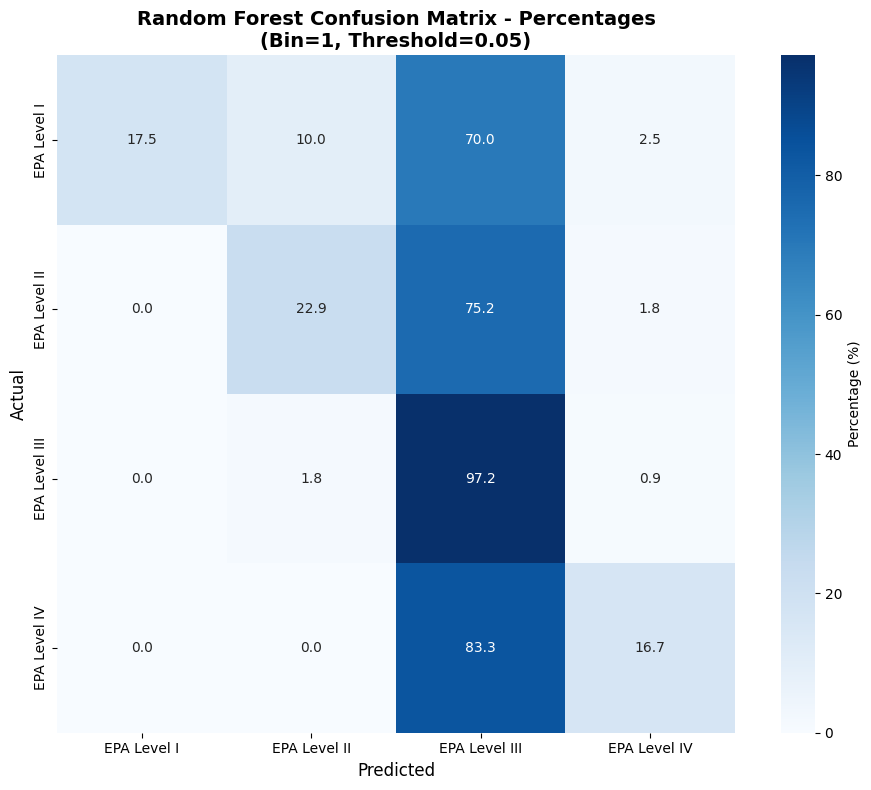


Random Forest Percentage breakdown by actual label (Bin=1, Threshold=0.05):

EPA Level I (Total: 80 samples):
  → EPA Level I: 17.5% (14/80 samples)
  → EPA Level II: 10.0% (8/80 samples)
  → EPA Level III: 70.0% (56/80 samples)
  → EPA Level IV: 2.5% (2/80 samples)

EPA Level II (Total: 109 samples):
  → EPA Level I: 0.0% (0/109 samples)
  → EPA Level II: 22.9% (25/109 samples)
  → EPA Level III: 75.2% (82/109 samples)
  → EPA Level IV: 1.8% (2/109 samples)

EPA Level III (Total: 218 samples):
  → EPA Level I: 0.0% (0/218 samples)
  → EPA Level II: 1.8% (4/218 samples)
  → EPA Level III: 97.2% (212/218 samples)
  → EPA Level IV: 0.9% (2/218 samples)

EPA Level IV (Total: 6 samples):
  → EPA Level I: 0.0% (0/6 samples)
  → EPA Level II: 0.0% (0/6 samples)
  → EPA Level III: 83.3% (5/6 samples)
  → EPA Level IV: 16.7% (1/6 samples)


In [7]:
# Example usage for Random Forest Confusion Matrix
# Replace with your actual folder path, folder name, and parameter values
cm_percent_rf, df_rf = create_percentage_confusion_matrix_random_forest(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="random_forest_df6_super_test",  # Update with your RF results folder name
    bin_size=1,
    threshold_size=0.05,
    save_plots=False
)

## Heatmap

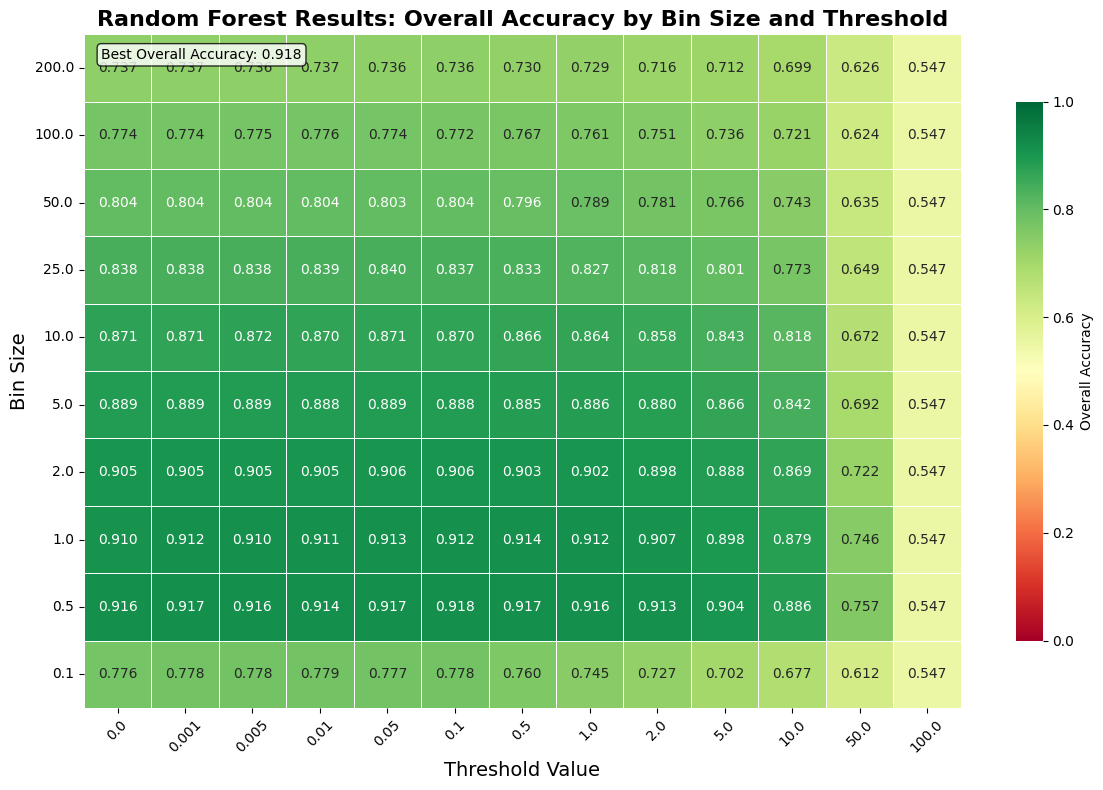

Threshold,0.000,0.001,0.005,0.010,0.050,0.100,0.500,1.000,2.000,5.000,10.000,50.000,100.000
BinSize,,,,,,,,,,,,,
0.1,0.776028,0.778047,0.777509,0.778585,0.777441,0.777778,0.760011,0.745138,0.727101,0.702335,0.676627,0.612356,0.547009
0.5,0.916482,0.917087,0.915943,0.914126,0.916616,0.917895,0.917087,0.915876,0.912511,0.904233,0.886130,0.757251,0.547009
1.0,0.909954,0.912309,0.910357,0.911098,0.913184,0.911973,0.913722,0.912242,0.907329,0.898109,0.879400,0.746147,0.547009
2.0,0.905108,0.905041,0.904704,0.905108,0.905714,0.906185,0.903493,0.902416,0.897570,0.888081,0.869372,0.721852,0.547009
5.0,0.888620,0.888889,0.888822,0.888485,0.888754,0.888216,0.884918,0.885591,0.879736,0.865603,0.842385,0.691904,0.547009
10.0,0.871256,0.870987,0.872333,0.869709,0.870853,0.870112,0.866007,0.863719,0.858066,0.842654,0.817821,0.671580,0.547009
25.0,0.837943,0.837607,0.838213,0.838818,0.839828,0.836597,0.833367,0.826502,0.817754,0.800861,0.773067,0.649236,0.547009
50.0,0.803890,0.803890,0.804226,0.804226,0.803082,0.803823,0.795545,0.789151,0.780874,0.765933,0.743051,0.634632,0.547009
100.0,0.773874,0.773673,0.775490,0.775624,0.774346,0.771586,0.766808,0.761155,0.750723,0.735783,0.720641,0.623932,0.547009


In [16]:
# Configurable Accuracy Heatmap Function for Random Forest
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

def response_to_epa_class_local_rf(response_value):
    """Convert Response value to EPA toxicity class"""
    if response_value <= 50:
        return 1  # EPA Level 1
    elif response_value <= 500:
        return 2  # EPA Level 2
    elif response_value <= 5000:
        return 3  # EPA Level 3
    else:
        return 4  # EPA Level 4

def calculate_class_accuracy_rf(y_true, y_pred, target_class):
    """Calculate accuracy for a specific class"""
    # Convert to 0-based indexing
    target_class_idx = target_class - 1
    
    # Get mask for samples that actually belong to target class
    class_mask = y_true == target_class_idx
    
    if np.sum(class_mask) == 0:
        return np.nan  # No samples of this class
    
    # Calculate accuracy for this class (correct predictions / total actual samples of this class)
    correct_for_class = np.sum((y_true == y_pred) & class_mask)
    total_for_class = np.sum(class_mask)
    
    return correct_for_class / total_for_class

def parse_rf_classification_dataset_name(dataset_name):
    """Extract bin size and threshold from random forest classification dataset name"""
    # Remove 'rf_' prefix
    name_part = dataset_name.replace('rf_', '') 
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

def load_and_process_rf_classification_data(folder_path):
    """Load and process random forest classification data from the specified folder"""
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"Error: Folder {folder_path} does not exist!")
        return pd.DataFrame()
    
    # Get all .parquet files in the folder
    parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]
    dataset_names = [f.replace('.parquet', '') for f in parquet_files]

    if not dataset_names:
        print(f"Warning: No .parquet files found in {folder_path}")
        return pd.DataFrame()

    # Initialize storage for classification results
    classification_results = []

    # Process classification datasets
    for i, dataset_name in enumerate(sorted(dataset_names), 1):
        try:
            # Load the classification dataset
            file_path = os.path.join(folder_path, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)
            
            # Check if required columns exist
            if 'rf_predicted_epa_class' not in df.columns:
                print(f"  Warning: 'rf_predicted_epa_class' column not found, skipping...")
                continue
            
            # Get predictions and true values
            y_pred_class = df['rf_predicted_epa_class']  # Predicted EPA classes
            
            # Get true labels - prioritize EPA_level if available, otherwise derive from Response
            if 'EPA_level' in df.columns:
                y_true_class = df['EPA_level']  # Should be 1,2,3,4
            elif 'Response' in df.columns:
                y_true_class = df['Response'].apply(response_to_epa_class_local_rf)
            else:
                print(f"  Warning: Neither 'EPA_level' nor 'Response' column found, skipping...")
                continue
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_class.isna() | y_true_class.isna())
            y_pred_class_clean = y_pred_class[valid_mask]
            y_true_class_clean = y_true_class[valid_mask]
            
            if len(y_pred_class_clean) < 10:  # Skip if too few samples
                print(f"  Too few samples, skipping...")
                continue
            
            # Convert to 0-based indexing for sklearn functions
            y_true_class_clean_0based = y_true_class_clean - 1
            y_pred_class_clean_0based = y_pred_class_clean - 1
            
            # Calculate overall accuracy
            overall_accuracy = accuracy_score(y_true_class_clean_0based, y_pred_class_clean_0based)
            
            # Calculate individual class accuracies
            class1_accuracy = calculate_class_accuracy_rf(y_true_class_clean_0based, y_pred_class_clean_0based, 1)
            class2_accuracy = calculate_class_accuracy_rf(y_true_class_clean_0based, y_pred_class_clean_0based, 2)
            class3_accuracy = calculate_class_accuracy_rf(y_true_class_clean_0based, y_pred_class_clean_0based, 3)
            class4_accuracy = calculate_class_accuracy_rf(y_true_class_clean_0based, y_pred_class_clean_0based, 4)
            
            # Store results
            classification_results.append({
                'Dataset': dataset_name,
                'Overall_Accuracy': overall_accuracy,
                'Class1_Accuracy': class1_accuracy,
                'Class2_Accuracy': class2_accuracy,
                'Class3_Accuracy': class3_accuracy,
                'Class4_Accuracy': class4_accuracy,
                'Samples': len(y_pred_class_clean)
            })
            
        except Exception as e:
            print(f"  ✗ Error processing {dataset_name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(classification_results)

    if results_df.empty:
        print("Warning: No datasets were successfully processed!")
        return results_df

    # Add bin_size and threshold columns
    bin_sizes = []
    thresholds = []

    for dataset_name in results_df['Dataset']:
        bin_size, threshold = parse_rf_classification_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)

    results_df['BinSize'] = bin_sizes
    results_df['Threshold'] = thresholds

    # Remove duplicates
    results_df = results_df.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    return results_df

# Main function to create accuracy heatmap with configurable parameters for Random Forest
def create_detailed_heatmap_rf_accuracy(folder_path, metric='average', colormap='RdYlGn', figsize=(12, 8)):
    """
    Create a detailed heatmap for Random Forest Classification Accuracy
    
    Parameters:
    folder_path (str): Path to folder containing classification result files
    metric (str): Type of accuracy to plot
        - 'average': Overall accuracy
        - '1', '2', '3', '4': Individual class accuracy (EPA Level 1-4)
    colormap (str): Color scheme for the heatmap (e.g., 'RdYlGn', 'viridis', 'Blues', 'Reds', 'Greens', 'Purples')
    figsize (tuple): Figure size as (width, height)
    
    Returns:
    pandas.DataFrame: Pivot table with accuracy data, or None if no data available
    """
    
    # Load and process data from the specified folder
    df_results = load_and_process_rf_classification_data(folder_path)
    
    if df_results.empty:
        print("No data available to create heatmap!")
        print("Please ensure the folder contains valid .parquet files with required columns.")
        return None
    
    # Map metric types to column names and display names
    metric_mapping = {
        'average': ('Overall_Accuracy', 'Overall Accuracy'),
        '1': ('Class1_Accuracy', 'EPA Level I Accuracy'),
        '2': ('Class2_Accuracy', 'EPA Level II Accuracy'),
        '3': ('Class3_Accuracy', 'EPA Level III Accuracy'),
        '4': ('Class4_Accuracy', 'EPA Level IV Accuracy')
    }
    
    if metric not in metric_mapping:
        raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    
    column_name, display_name = metric_mapping[metric]
    
    # Create pivot table
    accuracy_pivot = df_results.pivot(index='BinSize', columns='Threshold', values=column_name)
    
    # List all expected thresholds and bin sizes
    thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200]
    
    # Reindex pivot table
    accuracy_pivot = accuracy_pivot.reindex(columns=thresholds_subset, index=bins_subset)
    
    plt.figure(figsize=figsize)
    
    # Create heatmap
    ax = sns.heatmap(accuracy_pivot, 
                     annot=True, 
                     fmt='.3f', 
                     cmap=colormap,
                     square=False,
                     linewidths=0.5,
                     vmin=0,
                     vmax=1,
                     cbar_kws={'label': display_name, 'shrink': 0.8})
    
    plt.title(f'Random Forest Results: {display_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_acc = accuracy_pivot.max().max()
    plt.text(0.02, 0.98, f'Best {display_name}: {best_acc:.3f}', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy_pivot

# Define the folder path for Random Forest results
folder_path_rf = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/random_forest_df6"

# Overall accuracy with default green color scheme
create_detailed_heatmap_rf_accuracy(folder_path_rf, metric='average', colormap='RdYlGn')

# Old Version saved for posterity

In [17]:
# Configurable Accuracy Heatmap Function
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

def response_to_epa_class_local(response_value):
    """Convert Response value to EPA toxicity class"""
    if response_value <= 50:
        return 1  # EPA Level 1
    elif response_value <= 500:
        return 2  # EPA Level 2
    elif response_value <= 5000:
        return 3  # EPA Level 3
    else:
        return 4  # EPA Level 4

def calculate_class_accuracy(y_true, y_pred, target_class):
    """Calculate accuracy for a specific class"""
    # Convert to 0-based indexing
    target_class_idx = target_class - 1
    
    # Get mask for samples that actually belong to target class
    class_mask = y_true == target_class_idx
    
    if np.sum(class_mask) == 0:
        return np.nan  # No samples of this class
    
    # Calculate accuracy for this class (correct predictions / total actual samples of this class)
    correct_for_class = np.sum((y_true == y_pred) & class_mask)
    total_for_class = np.sum(class_mask)
    
    return correct_for_class / total_for_class

def parse_cond_enc_classification_dataset_name(dataset_name):
    """Extract bin size and threshold from full conditional encoder classification dataset name"""
    # Remove 'cond_enc_' prefix
    name_part = dataset_name.replace('cond_enc_', '') 
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

def load_and_process_classification_data(folder_path):
    """Load and process classification data from the specified folder"""
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"Error: Folder {folder_path} does not exist!")
        return pd.DataFrame()
    
    # Get all .parquet files in the folder
    parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]
    dataset_names = [f.replace('.parquet', '') for f in parquet_files]

    if not dataset_names:
        print(f"Warning: No .parquet files found in {folder_path}")
        return pd.DataFrame()

    # Initialize storage for classification results
    classification_results = []

    # Process classification datasets
    for i, dataset_name in enumerate(sorted(dataset_names), 1):
        try:
            # Load the classification dataset
            file_path = os.path.join(folder_path, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)
            
            # Check if required columns exist
            if 'cond_tox_pred_class' not in df.columns:
                print(f"  Warning: 'cond_tox_pred_class' column not found, skipping...")
                continue
            
            if 'Response' not in df.columns:
                print(f"  Warning: 'Response' column not found, skipping...")
                continue
            
            # Get predictions and true values
            y_pred_class = df['cond_tox_pred_class']  # Predicted EPA classes
            y_true_response = df['Response']  # True toxicity values
            
            # Convert true response values to EPA classes
            y_true_class = y_true_response.apply(response_to_epa_class_local)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_class.isna() | y_true_class.isna())
            y_pred_class_clean = y_pred_class[valid_mask]
            y_true_class_clean = y_true_class[valid_mask]
            
            if len(y_pred_class_clean) < 10:  # Skip if too few samples
                print(f"  Too few samples, skipping...")
                continue
            
            # Convert to 0-based indexing for sklearn functions
            y_true_class_clean_0based = y_true_class_clean - 1
            
            # Calculate overall accuracy
            overall_accuracy = accuracy_score(y_true_class_clean_0based, y_pred_class_clean)
            
            # Calculate individual class accuracies
            class1_accuracy = calculate_class_accuracy(y_true_class_clean_0based, y_pred_class_clean, 1)
            class2_accuracy = calculate_class_accuracy(y_true_class_clean_0based, y_pred_class_clean, 2)
            class3_accuracy = calculate_class_accuracy(y_true_class_clean_0based, y_pred_class_clean, 3)
            class4_accuracy = calculate_class_accuracy(y_true_class_clean_0based, y_pred_class_clean, 4)
            
            # Store results
            classification_results.append({
                'Dataset': dataset_name,
                'Overall_Accuracy': overall_accuracy,
                'Class1_Accuracy': class1_accuracy,
                'Class2_Accuracy': class2_accuracy,
                'Class3_Accuracy': class3_accuracy,
                'Class4_Accuracy': class4_accuracy,
                'Samples': len(y_pred_class_clean)
            })
            
        except Exception as e:
            print(f"  ✗ Error processing {dataset_name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(classification_results)

    if results_df.empty:
        print("Warning: No datasets were successfully processed!")
        return results_df

    # Add bin_size and threshold columns
    bin_sizes = []
    thresholds = []

    for dataset_name in results_df['Dataset']:
        bin_size, threshold = parse_cond_enc_classification_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)

    results_df['BinSize'] = bin_sizes
    results_df['Threshold'] = thresholds

    # Remove duplicates
    results_df = results_df.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    return results_df

# Main function to create accuracy heatmap with configurable parameters
def create_detailed_heatmap_cond_enc_accuracy(folder_path, metric='average', colormap='RdYlGn', figsize=(12, 8)):
    """
    Create a detailed heatmap for Classification Accuracy
    
    Parameters:
    folder_path (str): Path to folder containing classification result files
    metric (str): Type of accuracy to plot
        - 'average': Overall accuracy
        - '1', '2', '3', '4': Individual class accuracy (EPA Level 1-4)
    colormap (str): Color scheme for the heatmap (e.g., 'RdYlGn', 'viridis', 'Blues', 'Reds', 'Greens', 'Purples')
    figsize (tuple): Figure size as (width, height)
    
    Returns:
    pandas.DataFrame: Pivot table with accuracy data, or None if no data available
    """
    
    # Load and process data from the specified folder
    df_results = load_and_process_classification_data(folder_path)
    
    if df_results.empty:
        print("No data available to create heatmap!")
        print("Please ensure the folder contains valid .parquet files with required columns.")
        return None
    
    # Map metric types to column names and display names
    metric_mapping = {
        'average': ('Overall_Accuracy', 'Overall Accuracy'),
        '1': ('Class1_Accuracy', 'EPA Level I Accuracy'),
        '2': ('Class2_Accuracy', 'EPA Level II Accuracy'),
        '3': ('Class3_Accuracy', 'EPA Level III Accuracy'),
        '4': ('Class4_Accuracy', 'EPA Level IV Accuracy')
    }
    
    if metric not in metric_mapping:
        raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    
    column_name, display_name = metric_mapping[metric]
    
    # Create pivot table
    accuracy_pivot = df_results.pivot(index='BinSize', columns='Threshold', values=column_name)
    
    # List all expected thresholds and bin sizes
    thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]
    
    # Reindex pivot table
    accuracy_pivot = accuracy_pivot.reindex(columns=thresholds_subset, index=bins_subset)
    
    plt.figure(figsize=figsize)
    
    # Create heatmap
    ax = sns.heatmap(accuracy_pivot, 
                     annot=True, 
                     fmt='.3f', 
                     cmap=colormap,
                     square=False,
                     linewidths=0.5,
                     vmin=0,
                     vmax=1,
                     cbar_kws={'label': display_name, 'shrink': 0.8})
    
    # Rectangle highlighting has been removed
    
    plt.title(f'Classification Results: {display_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_acc = accuracy_pivot.max().max()
    plt.text(0.02, 0.98, f'Best {display_name}: {best_acc:.3f}', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy_pivot
